# Distribution Planning Benchmark

This notebook imports saved distribution-planning runs from `results/distribution`. It is analysis-only and does not run training.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from mfc.visualization import (
    best_runs_by_label,
    discrete_transport_tv_bound_table,
    load_runs,
    objective_table,
    plot_distribution_comparison,
    plot_state_flow,
    plot_validation_rewards,
    runtime_table,
)

ENV = 'distribution'
RESULTS_ROOT = ROOT / 'results'
runs = load_runs(RESULTS_ROOT, env=ENV)
print(f'Loaded {len(runs)} saved runs from {RESULTS_ROOT / ENV}')

Loaded 25 saved runs from /home/adonis/Internship/mfc/results/distribution


## Validation Reward

Mean validation reward over training, with one standard deviation across seeds. Higher is better because the reward is the negative mismatch and movement cost.

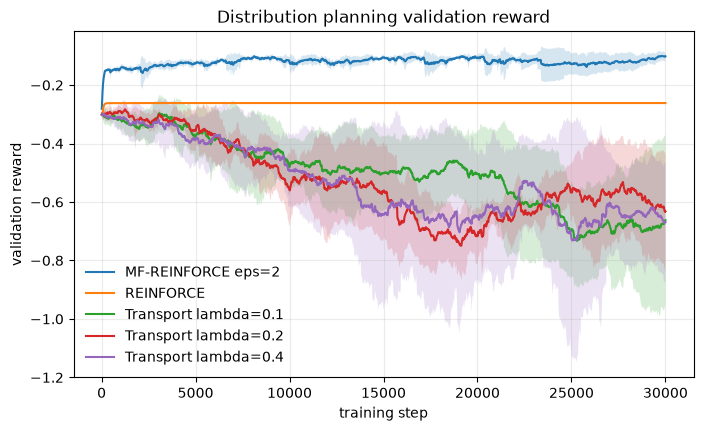

In [2]:
if not runs:
    print('No saved runs yet. Run scripts/run.py before executing the analysis cells.')
else:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_validation_rewards(runs, env=ENV, horizon=5, flow='exact', ax=ax)
    ax.set_title('Distribution planning validation reward')
    plt.show()

## Initial, Target, and Learned Distributions

Bar charts comparing the uniform initial law, the fixed target law, and the terminal population distribution induced by the best saved policy for each configuration.

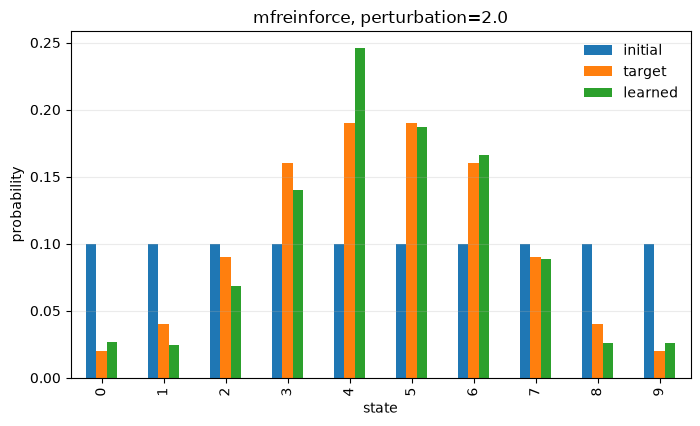

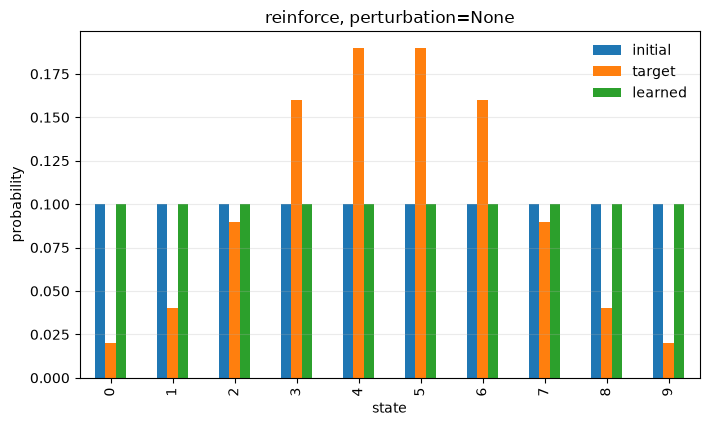

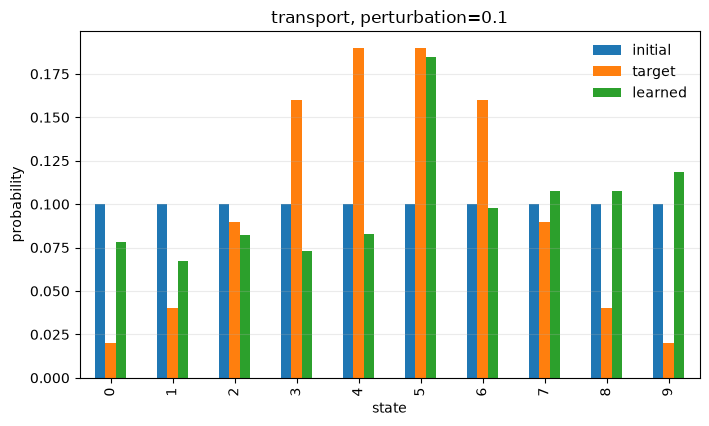

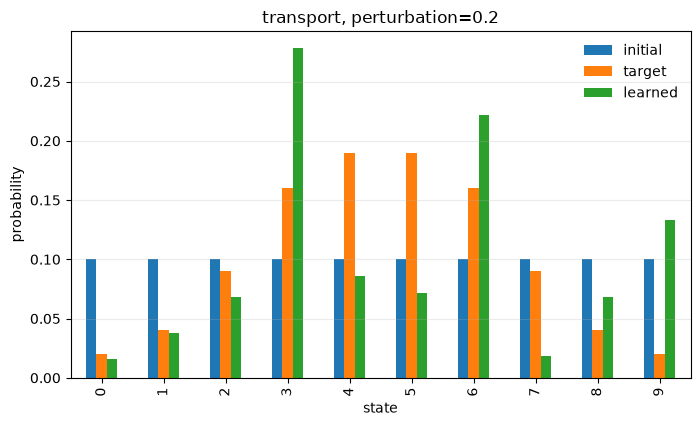

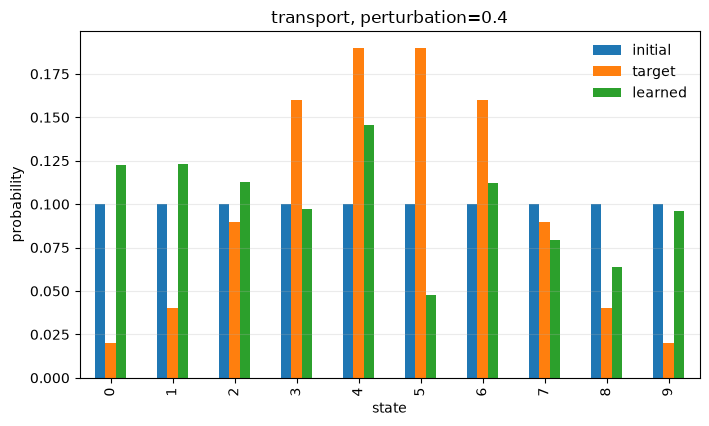

In [3]:
for run in best_runs_by_label(runs):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_distribution_comparison(run, ax=ax)
    meta = run['metadata']
    ax.set_title(f"{meta['algorithm']}, perturbation={meta['perturbation']}")
    plt.show()

## Learned Flow Over Time

State-probability trajectories under selected learned policies. These curves show whether the policy moves mass coherently toward the target or oscillates around it.

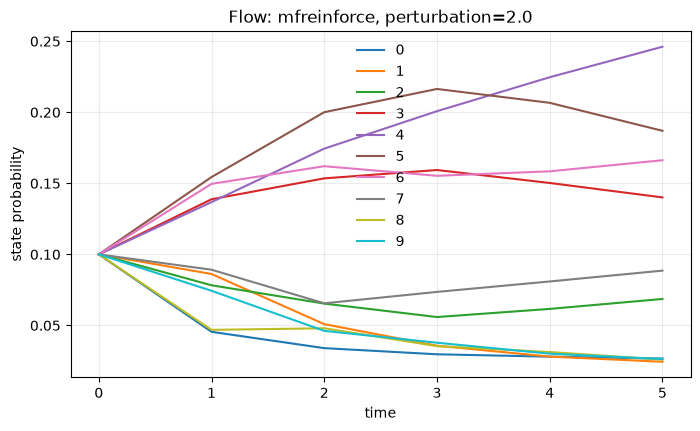

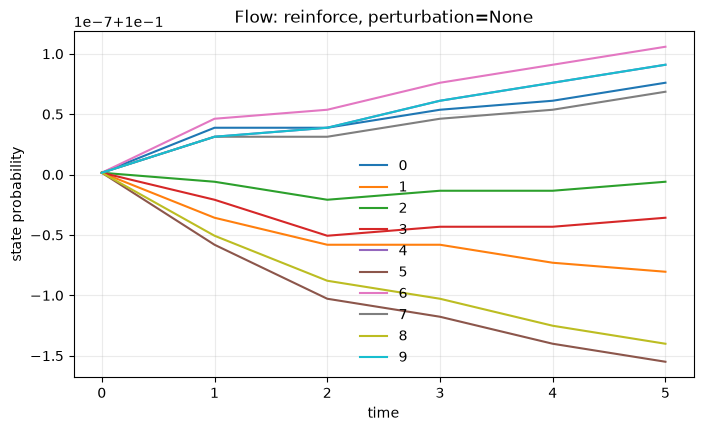

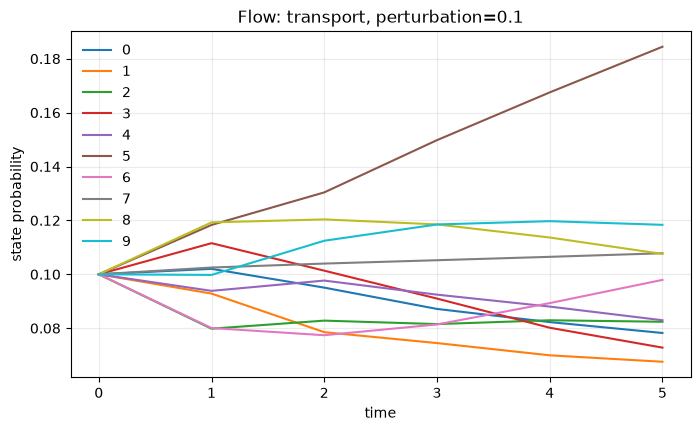

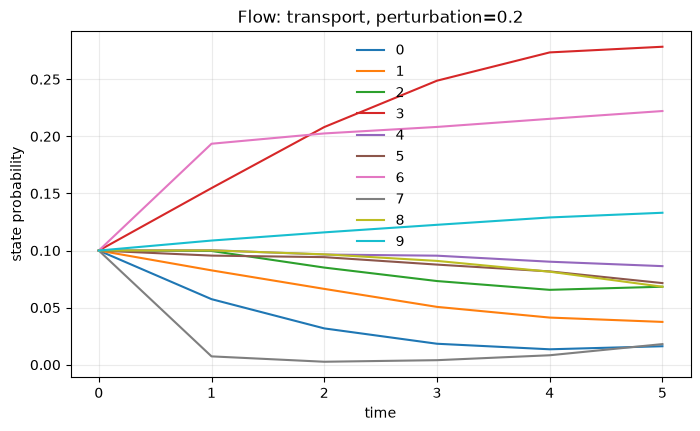

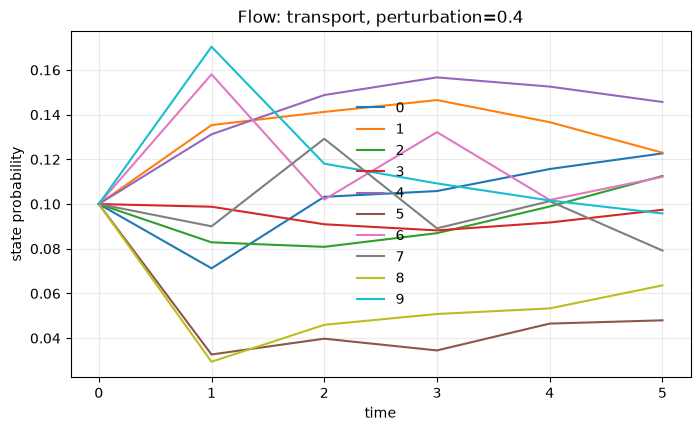

In [4]:
for run in best_runs_by_label(runs):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_state_flow(run, ax=ax)
    meta = run['metadata']
    ax.set_title(f"Flow: {meta['algorithm']}, perturbation={meta['perturbation']}")
    plt.show()

## Transport Perturbation Bound

For simplex transport, the total-variation distance between the sampled perturbed law and the unperturbed law is bounded by `lambda`.

In [5]:
tv_bounds = discrete_transport_tv_bound_table(runs)
display(tv_bounds if not tv_bounds.empty else pd.DataFrame({'message': ['No transport runs found yet.']}))

,env,label,flow,horizon,seed,lambda,max_tv_upper_bound,satisfies_lambda_bound
0,distribution,Transport lambda=0.1,exact,5,0,0.1,0.099654,True
1,distribution,Transport lambda=0.1,exact,5,1,0.1,0.099833,True
2,distribution,Transport lambda=0.1,exact,5,2,0.1,0.093245,True
3,distribution,Transport lambda=0.1,exact,5,3,0.1,0.099995,True
4,distribution,Transport lambda=0.1,exact,5,4,0.1,0.099359,True
5,distribution,Transport lambda=0.2,exact,5,0,0.2,0.196201,True
6,distribution,Transport lambda=0.2,exact,5,1,0.2,0.199795,True
7,distribution,Transport lambda=0.2,exact,5,2,0.2,0.198060,True
8,distribution,Transport lambda=0.2,exact,5,3,0.2,0.199475,True
9,distribution,Transport lambda=0.2,exact,5,4,0.2,0.199925,True


## Objective and Runtime Tables

Final validation rewards, estimated simulator budgets, and runtime summaries.

In [6]:
display(objective_table(runs))
display(runtime_table(runs))

,env,label,flow,horizon,seed,validation_reward
0,distribution,MF-REINFORCE eps=2,exact,5,0,-0.090342
1,distribution,MF-REINFORCE eps=2,exact,5,1,-0.128468
2,distribution,MF-REINFORCE eps=2,exact,5,2,-0.088191
3,distribution,MF-REINFORCE eps=2,exact,5,3,-0.101692
4,distribution,MF-REINFORCE eps=2,exact,5,4,-0.099611
5,distribution,REINFORCE,exact,5,0,-0.261600
6,distribution,REINFORCE,exact,5,1,-0.261600
7,distribution,REINFORCE,exact,5,2,-0.261600
8,distribution,REINFORCE,exact,5,3,-0.261600
9,distribution,REINFORCE,exact,5,4,-0.261600


,env,algorithm,perturbation,horizon,flow,setup_seconds_mean,setup_seconds_std,train_step_seconds_mean,train_step_seconds_std,validation_seconds_mean,validation_seconds_std,elapsed_seconds_mean,elapsed_seconds_std,seconds_per_step_mean,wall_seconds_per_step_mean,validation_seconds_per_call_mean,simulator_budget_mean,n_runs
0,distribution,mfreinforce,2.0,5,exact,6.640437,0.272119,5510.587325,182.322302,81.666741,0.494835,5599.032219,182.706925,0.183686,0.186634,0.027222,2800.0,5
1,distribution,reinforce,NaN,5,exact,9.372002,1.251358,138.953467,3.123122,80.481031,0.875045,228.894752,4.654011,0.004632,0.007630,0.026827,2800.0,5
2,distribution,transport,0.1,5,exact,7.333143,0.479270,5609.550754,67.772727,81.083196,0.397095,5698.126090,67.315886,0.186985,0.189938,0.027028,2800.0,5
3,distribution,transport,0.2,5,exact,8.011771,1.348228,5504.273821,165.820686,81.685707,0.435520,5594.130651,166.733734,0.183476,0.186471,0.027229,2800.0,5
4,distribution,transport,0.4,5,exact,8.709723,1.775025,5311.952557,100.481418,80.823211,0.333166,5401.634807,99.309844,0.177065,0.180054,0.026941,2800.0,5
